In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

In [7]:
from google.colab import files
uploaded = files.upload()

Saving toxicity dataset.csv to toxicity dataset.csv


In [8]:
import pandas as pd

data = pd.read_csv("toxicity dataset.csv", encoding="utf-8")

print(data.head())
print("Dataset shape:", data.shape)

   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C  MDEO-22     Class  
0      

In [9]:
print(data.info())
print(data.describe())
print(data["Class"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 1204 entries, MATS3v to Class
dtypes: float64(1003), int64(200), object(1)
memory usage: 1.6+ MB
None
           MATS3v    nHBint10      MATS3s      MATS3p  nHBDon_Lipinski  \
count  171.000000  171.000000  171.000000  171.000000       171.000000   
mean    -0.031244    0.315789   -0.001001   -0.061501         0.994152   
std      0.063559    0.762918    0.063928    0.072891         1.108773   
min     -0.311500    0.000000   -0.184600   -0.348500         0.000000   
25%     -0.066700    0.000000   -0.036000   -0.099550         0.000000   
50%     -0.032500    0.000000   -0.002000   -0.059400         1.000000   
75%      0.004850    0.000000    0.029000   -0.017100         2.000000   
max      0.141100    4.000000    0.218100    0.129000         6.000000   

        minHBint8      MATS3e      MATS3c   minHBint2      MATS3m  ...  \
count  171.000000  171.000000  171.000000  171.000000  171.000000  ...   
me

In [12]:
data["Class"] = data["Class"].replace({
    "NonToxic":0,
    "Toxic":1
})

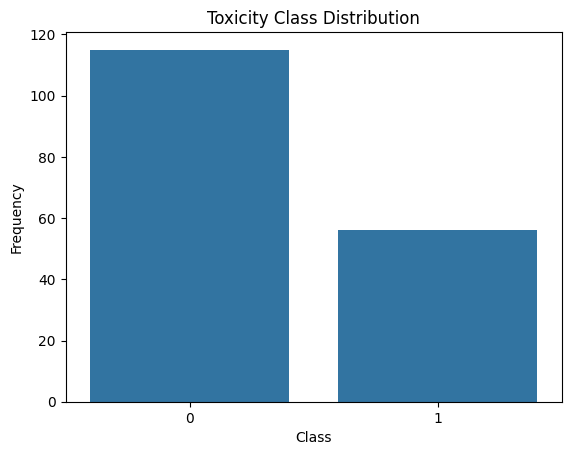

In [13]:
sns.barplot(x=data["Class"].value_counts().index,
            y=data["Class"].value_counts().values)

plt.title("Toxicity Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

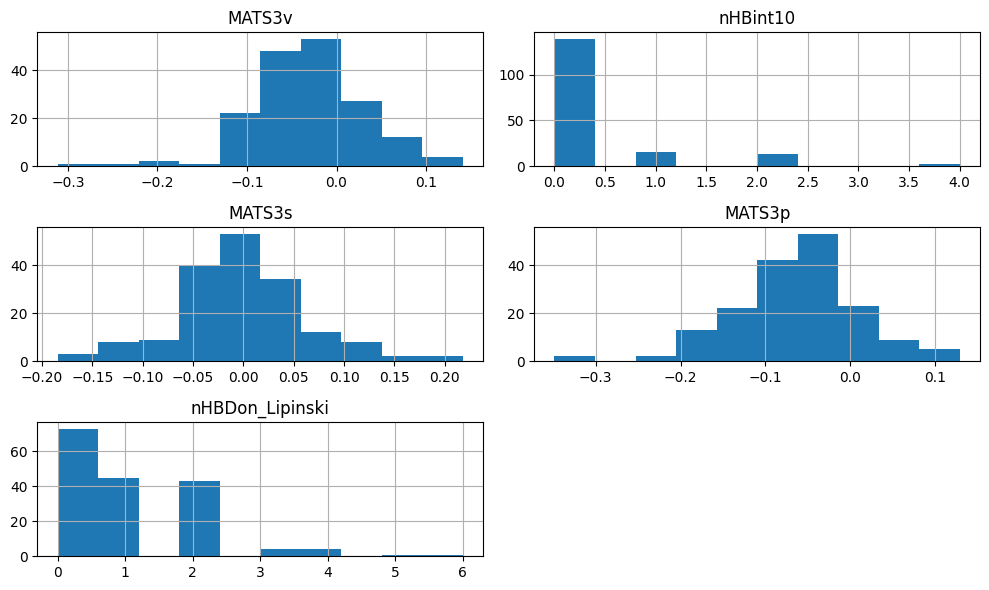

In [14]:
data.iloc[:, :5].hist(figsize=(10,6))
plt.tight_layout()
plt.show()

In [15]:
missing = data.isnull().sum()

print(missing[missing>0])

data = data.fillna(data.median(numeric_only=True))

Series([], dtype: int64)


In [17]:
X = data.drop("Class", axis=1)
y = data["Class"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=7
)

In [19]:
smote = SMOTE(random_state=7)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np

selector = SelectKBest(score_func=f_classif, k=25)

X_train_selected = selector.fit_transform(X_train_scaled, y_train_bal)
X_test_selected = selector.transform(X_test_scaled)

# replace any NaN values
X_train_selected = np.nan_to_num(X_train_selected)
X_test_selected = np.nan_to_num(X_test_selected)

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=250,
    random_state=7
)

rf_model.fit(X_train_selected, y_train_bal)

RandomForestClassifier(n_estimators=250, random_state=7)

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

scores = cross_val_score(
    rf_model,
    X_train_selected,
    y_train_bal,
    cv=cv,
    scoring="f1"
)

print("CV Scores:", scores)
print("Mean Score:", scores.mean())

CV Scores: [0.64864865 0.66666667 0.73684211 0.77777778 0.81081081]
Mean Score: 0.7281492018334124


In [29]:
predictions = rf_model.predict(X_test_selected)

              precision    recall  f1-score   support

           0       0.64      0.67      0.65        24
           1       0.20      0.18      0.19        11

    accuracy                           0.51        35
   macro avg       0.42      0.42      0.42        35
weighted avg       0.50      0.51      0.51        35



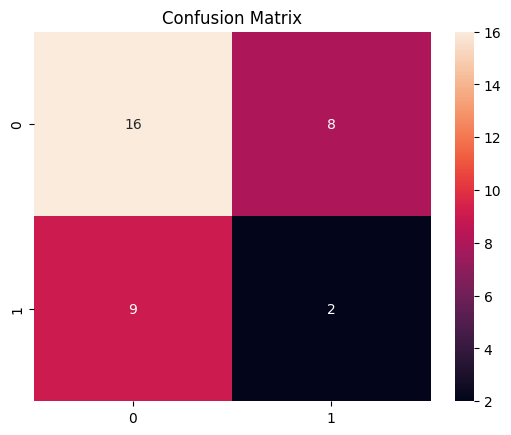

In [30]:
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()